In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("data_orders.csv")

In [3]:
df.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0
2,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0
3,13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0
4,21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10716 entries, 0 to 10715
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_datetime                 10716 non-null  str    
 1   origin_longitude               10716 non-null  float64
 2   origin_latitude                10716 non-null  float64
 3   m_order_eta                    2814 non-null   float64
 4   order_gk                       10716 non-null  int64  
 5   order_status_key               10716 non-null  int64  
 6   is_driver_assigned_key         10716 non-null  int64  
 7   cancellations_time_in_seconds  7307 non-null   float64
dtypes: float64(4), int64(3), str(1)
memory usage: 669.9 KB


In [5]:
df.shape

(10716, 8)

In [ ]:
df = df.drop_duplicates()
df.shape
# There's no duplicates.

(10716, 8)

In [6]:
df['order_datetime'] = pd.to_datetime(df['order_datetime'], format='%H:%M:%S')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10716 entries, 0 to 10715
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_datetime                 10716 non-null  datetime64[us]
 1   origin_longitude               10716 non-null  float64       
 2   origin_latitude                10716 non-null  float64       
 3   m_order_eta                    2814 non-null   float64       
 4   order_gk                       10716 non-null  int64         
 5   order_status_key               10716 non-null  int64         
 6   is_driver_assigned_key         10716 non-null  int64         
 7   cancellations_time_in_seconds  7307 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(3)
memory usage: 669.9 KB


In [7]:
df.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,1900-01-01 18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0
1,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0
2,1900-01-01 12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0
3,1900-01-01 13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0
4,1900-01-01 21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN


In [8]:
df['is_driver_assigned_key'] = df['is_driver_assigned_key'].replace(
    {0 :"not assigned",
     1 :"assigned"}
)
df.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,1900-01-01 18:08:07,-0.978916,51.456173,60.0,3000583041974,4,assigned,198.0
1,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,4,not assigned,128.0
2,1900-01-01 12:07:50,-0.969520,51.455544,477.0,3000582891479,4,assigned,46.0
3,1900-01-01 13:50:20,-1.054671,51.460544,658.0,3000582941169,4,assigned,62.0
4,1900-01-01 21:24:45,-0.967605,51.458236,NaN,3000583140877,9,not assigned,NaN


In [9]:
df['order_status_key'] = df['order_status_key'].replace(
    {
        4:"client cancelled",
        9:"system rejected"
    }
)
df.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,1900-01-01 18:08:07,-0.978916,51.456173,60.0,3000583041974,client cancelled,assigned,198.0
1,1900-01-01 20:57:32,-0.950385,51.456843,NaN,3000583116437,client cancelled,not assigned,128.0
2,1900-01-01 12:07:50,-0.969520,51.455544,477.0,3000582891479,client cancelled,assigned,46.0
3,1900-01-01 13:50:20,-1.054671,51.460544,658.0,3000582941169,client cancelled,assigned,62.0
4,1900-01-01 21:24:45,-0.967605,51.458236,NaN,3000583140877,system rejected,not assigned,NaN


### 📊 Order Failure Distribution Analysis

Analyse the reasons for failure by building up the order distribution:
* **Pre & Post Assignment:** Cancellations before and after driver assignment.
* **Order Rejections:** Main reasons for order rejection.

> 💡 **Question:** Which category has the highest number of orders?

In [100]:
pd.crosstab(df['is_driver_assigned_key'],df['order_status_key'])

order_status_key,client cancelled,system rejected
is_driver_assigned_key,,
assigned,2811,3
not assigned,4496,3406


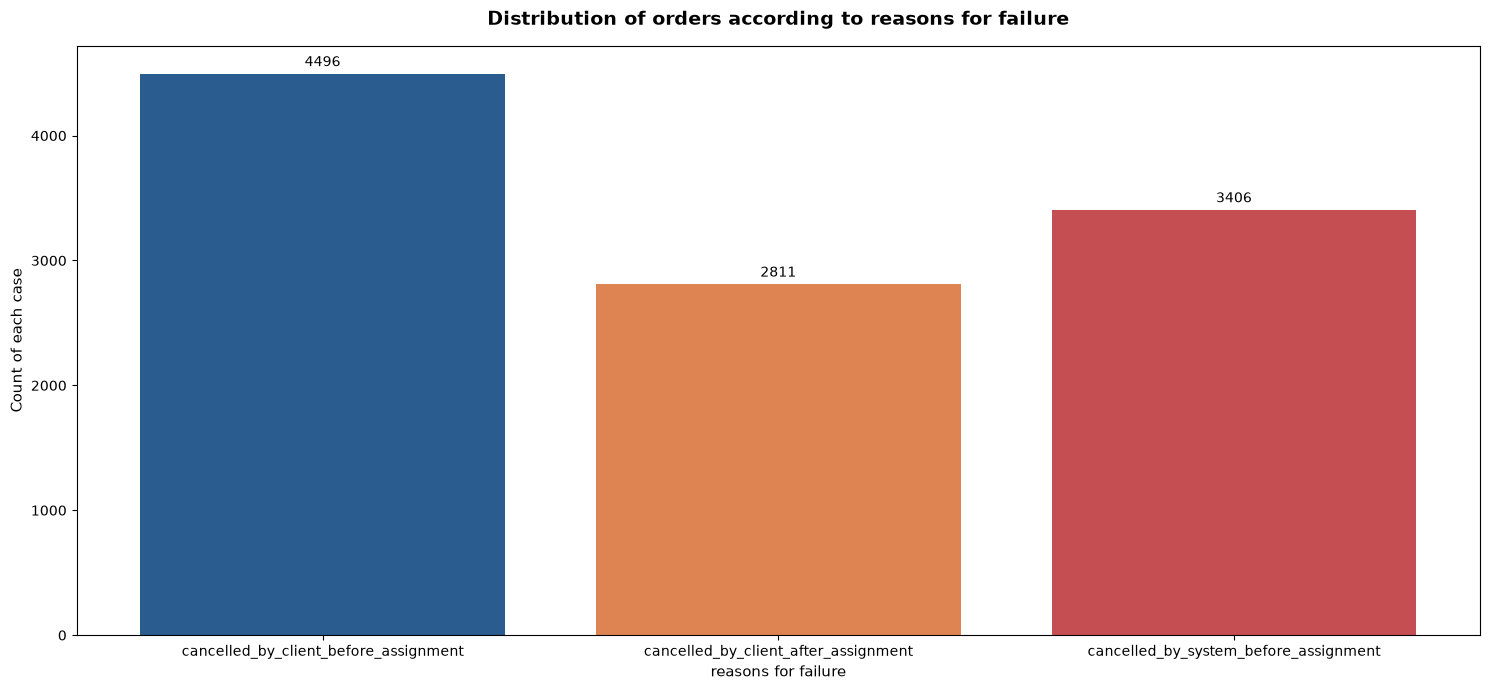

In [10]:
cancelled_by_client_before_assignment = df.loc[
                                                    (df['order_status_key']=='client cancelled') & 
                                                    (df['is_driver_assigned_key']=='not assigned')
                                                ]
cancelled_by_client_after_assignment = df.loc[
                                                    (df['order_status_key']=='client cancelled') & 
                                                    (df['is_driver_assigned_key']=='assigned')
                                                ]
cancelled_by_system_before_assignment = df.loc[
                                                    (df['order_status_key']=='system rejected') & 
                                                    (df['is_driver_assigned_key']=='not assigned')
                                                ]
cancelled_by_system_after_assignment = df.loc[
                                                    (df['order_status_key']=='system rejected') & 
                                                    (df['is_driver_assigned_key']=='assigned')
                                                ]


failure_distribution_df = pd.Series(
    {"cancelled_by_client_before_assignment":len(cancelled_by_client_before_assignment),
    "cancelled_by_client_after_assignment":len(cancelled_by_client_after_assignment),
    "cancelled_by_system_before_assignment":len(cancelled_by_system_before_assignment),
    }
)


plt.figure(figsize=(15,7))
bars = plt.bar(x=failure_distribution_df.index, height=failure_distribution_df.values, color=["#2b5c8f", "#DD8452", "#C44E52"])

plt.bar_label(bars, padding=3)
plt.title("Distribution of orders according to reasons for failure",fontsize=14, pad=15, fontweight='bold')
plt.xlabel("reasons for failure", fontsize=11)
plt.ylabel("Count of each case", fontsize=11)
plt.tight_layout()
plt.savefig("failure_reasons.png", dpi=150, bbox_inches='tight')
plt.show()

### 📊 Failed Orders Distribution by Hour

Plot the distribution of failed orders across hours of the day:
* **Hourly Trend:** Check if certain hours have an abnormally high proportion of specific failure categories.
* **Peak Fails:** Identify which hours experience the highest overall failure counts.

> 💡 **Question:** How can these hour-based failure patterns be explained?

order_datetime
0      683
1      471
2      555
3      513
4      152
5       67
6      159
7      447
8     1082
9      412
10     170
11     193
12     256
13     366
14     256
15     439
16     356
17     541
18     414
19     317
20     469
21     846
22     716
23     836
Name: order_gk, dtype: int64


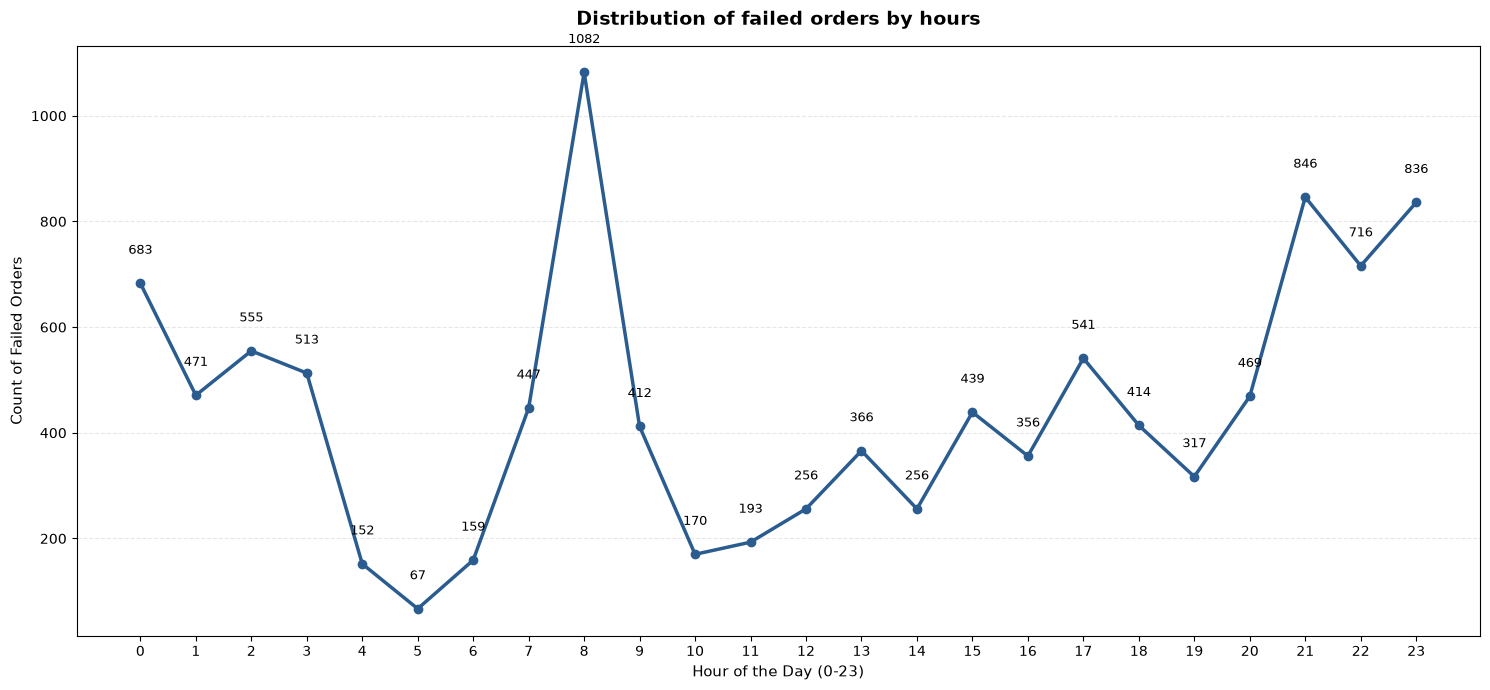

In [ ]:
df_grouped_by_hour = df.groupby(df['order_datetime'].dt.hour, as_index=True)['order_gk'].size()
print(df_grouped_by_hour)
plt.figure(figsize=(15,7))
plt.plot(df_grouped_by_hour.index, df_grouped_by_hour.values, color="#2b5c8f", linewidth=2.5, marker='o')
for x, y in zip(df_grouped_by_hour.index, df_grouped_by_hour.values):
    plt.text(x, y + 50, str(y), ha='center', va='bottom', fontsize=9)

plt.xticks(range(0,24))
plt.title("Distribution of failed orders by hours",fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Hour of the Day (0-23)", fontsize=11)
plt.ylabel("Count of Failed Orders", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("hourly_failures1.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(df_grouped_by_hour.sort_values(ascending=False))

print(df_grouped_by_hour.tolist())

order_datetime
8     1082
21     846
23     836
22     716
0      683
2      555
17     541
3      513
1      471
20     469
7      447
15     439
18     414
9      412
13     366
16     356
19     317
14     256
12     256
11     193
10     170
6      159
4      152
5       67
Name: order_gk, dtype: int64
[683, 471, 555, 513, 152, 67, 159, 447, 1082, 412, 170, 193, 256, 366, 256, 439, 356, 541, 414, 317, 469, 846, 716, 836]


10716 446.5 5089 0.47489734975737213


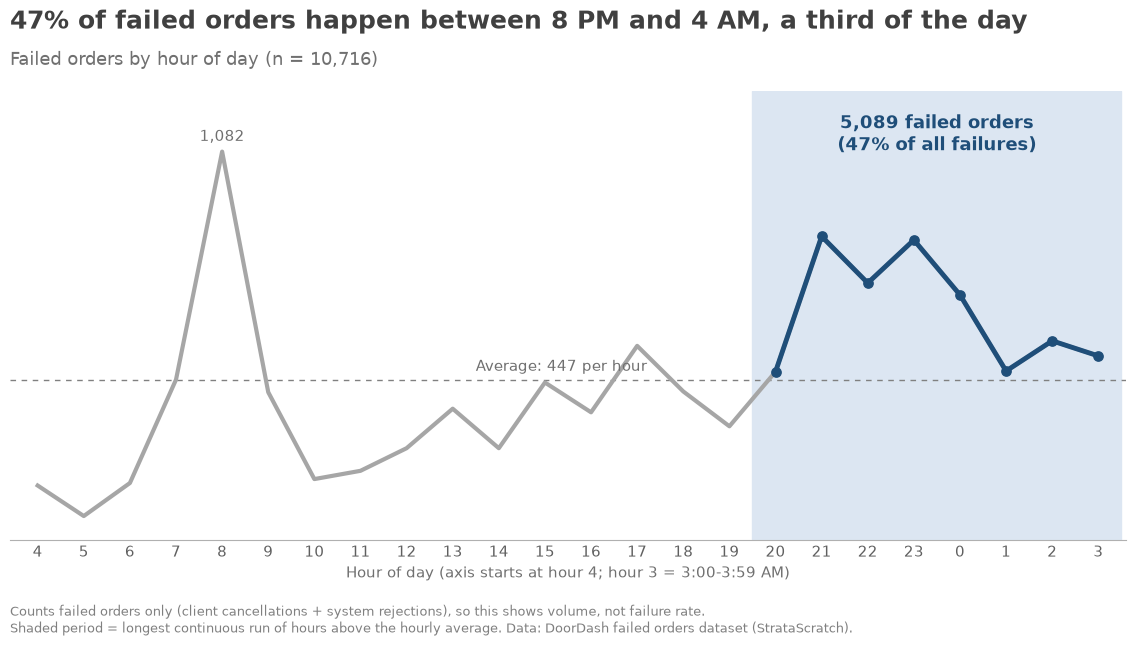

: 

In [ ]:
import matplotlib.pyplot as plt

counts = df_grouped_by_hour.tolist()  # hours 0..23
total = sum(counts)                       # 10,716
avg = total / 24                          # 446.5

order = list(range(4, 24)) + [0, 1, 2, 3]  # axis starts at hour 4
y = [counts[h] for h in order]
x = list(range(24))

hi_hours = [20, 21, 22, 23, 0, 1, 2, 3]
hi_idx = [i for i, h in enumerate(order) if h in hi_hours]   # 16..23
hi_total = sum(counts[h] for h in hi_hours)                  # 5,089

BLUE, GRAY = "#1F4E79", "#A6A6A6"
fig, ax = plt.subplots(figsize=(12, 6.6))

# shaded high-period
ax.axvspan(hi_idx[0] - 0.5, hi_idx[-1] + 0.5, color="#DCE6F2", zorder=0)

# gray line everywhere, blue over the high period
ax.plot(x, y, color=GRAY, lw=3, zorder=2)
ax.plot(hi_idx, [y[i] for i in hi_idx], color=BLUE, lw=3.5, zorder=3)
ax.scatter(hi_idx, [y[i] for i in hi_idx], color=BLUE, s=45, zorder=4)

# average line
ax.axhline(avg, color="#808080", lw=1, ls=(0, (4, 4)), zorder=1)
ax.text(9.5, avg + 25, f"Average: {int(avg + 0.5)} per hour", color="#707070", fontsize=11)

# hour 8 as gray context
i8 = order.index(8)
ax.text(i8, y[i8] + 30, f"{y[i8]:,}", ha="center", color="#707070", fontsize=11)

# main annotation inside shaded area
ax.text((hi_idx[0] + hi_idx[-1]) / 2, 1130,
        f"{hi_total:,} failed orders\n({hi_total/total:.0%} of all failures)",
        ha="center", va="center", color=BLUE, fontsize=13, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([str(h) for h in order], fontsize=11, color="#606060")
ax.set_xlabel("Hour of day (axis starts at hour 4; hour 3 = 3:00-3:59 AM)", fontsize=11, color="#707070")
ax.set_xlim(-0.6, 23.6); ax.set_ylim(0, 1250)
ax.set_yticks([])
for s in ["top", "right", "left"]: ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#B0B0B0"); ax.tick_params(axis="x", length=0)

fig.text(0.04, 0.945, f"{hi_total/total:.0%} of failed orders happen between 8 PM and 4 AM, a third of the day",
         fontsize=18, fontweight="bold", color="#404040")
fig.text(0.04, 0.89, f"Failed orders by hour of day (n = {total:,})", fontsize=13, color="#707070")
fig.text(0.04, 0.03,
         "Counts failed orders only (client cancellations + system rejections), so this shows volume, not failure rate.\n"
         "Shaded period = longest continuous run of hours above the hourly average. Data: DoorDash failed orders dataset (StrataScratch).",
         fontsize=9.5, color="#808080")
plt.subplots_adjust(left=0.04, right=0.97, top=0.85, bottom=0.17)
plt.savefig("failed_orders_by_hour_story.png", dpi=150)
print(total, avg, hi_total, hi_total/total)